In [ ]:
import scanpy as sc
import matplotlib
from matplotlib import rcParams

sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=100, dpi_save=300, color_map='Reds', facecolor='white')
matplotlib.rcParams.update({'figure.figsize': (6, 6)})


### day 1-6

In [12]:
samples = {}
base_path = "/mnt/yiming/public/celldiff_rawdata_0815/"

for i in range(1, 7):
    key = f"d{i}"
    file_path = f"{base_path}D{i}_rawData_output/output/filter_feature.h5ad"
    samples[key] = file_path

adatas = {}

for sample_id, filename in samples.items():
    sample_adata = sc.read_h5ad(filename)  # Use filename instead of file_path
    sample_adata.var_names_make_unique()
    adatas[sample_id] = sample_adata
    adatas[sample_id].obs['sample'] = sample_id

print(adatas)

{'d1': AnnData object with n_obs × n_vars = 5907 × 33487
    obs: 'sample'
    var: 'gene_symbols', 'd2': AnnData object with n_obs × n_vars = 8434 × 33336
    obs: 'sample'
    var: 'gene_symbols', 'd3': AnnData object with n_obs × n_vars = 5728 × 32999
    obs: 'sample'
    var: 'gene_symbols', 'd4': AnnData object with n_obs × n_vars = 5245 × 33235
    obs: 'sample'
    var: 'gene_symbols', 'd5': AnnData object with n_obs × n_vars = 15583 × 33852
    obs: 'sample'
    var: 'gene_symbols', 'd6': AnnData object with n_obs × n_vars = 10645 × 33734
    obs: 'sample'
    var: 'gene_symbols'}


In [13]:
for sample_name, sample_path in samples.items():
    adatas[sample_name].var["mt"] = adatas[sample_name].var_names.str.startswith("MT-") 
    sc.pp.calculate_qc_metrics(adatas[sample_name], qc_vars=["mt"], inplace=True, log1p=True)

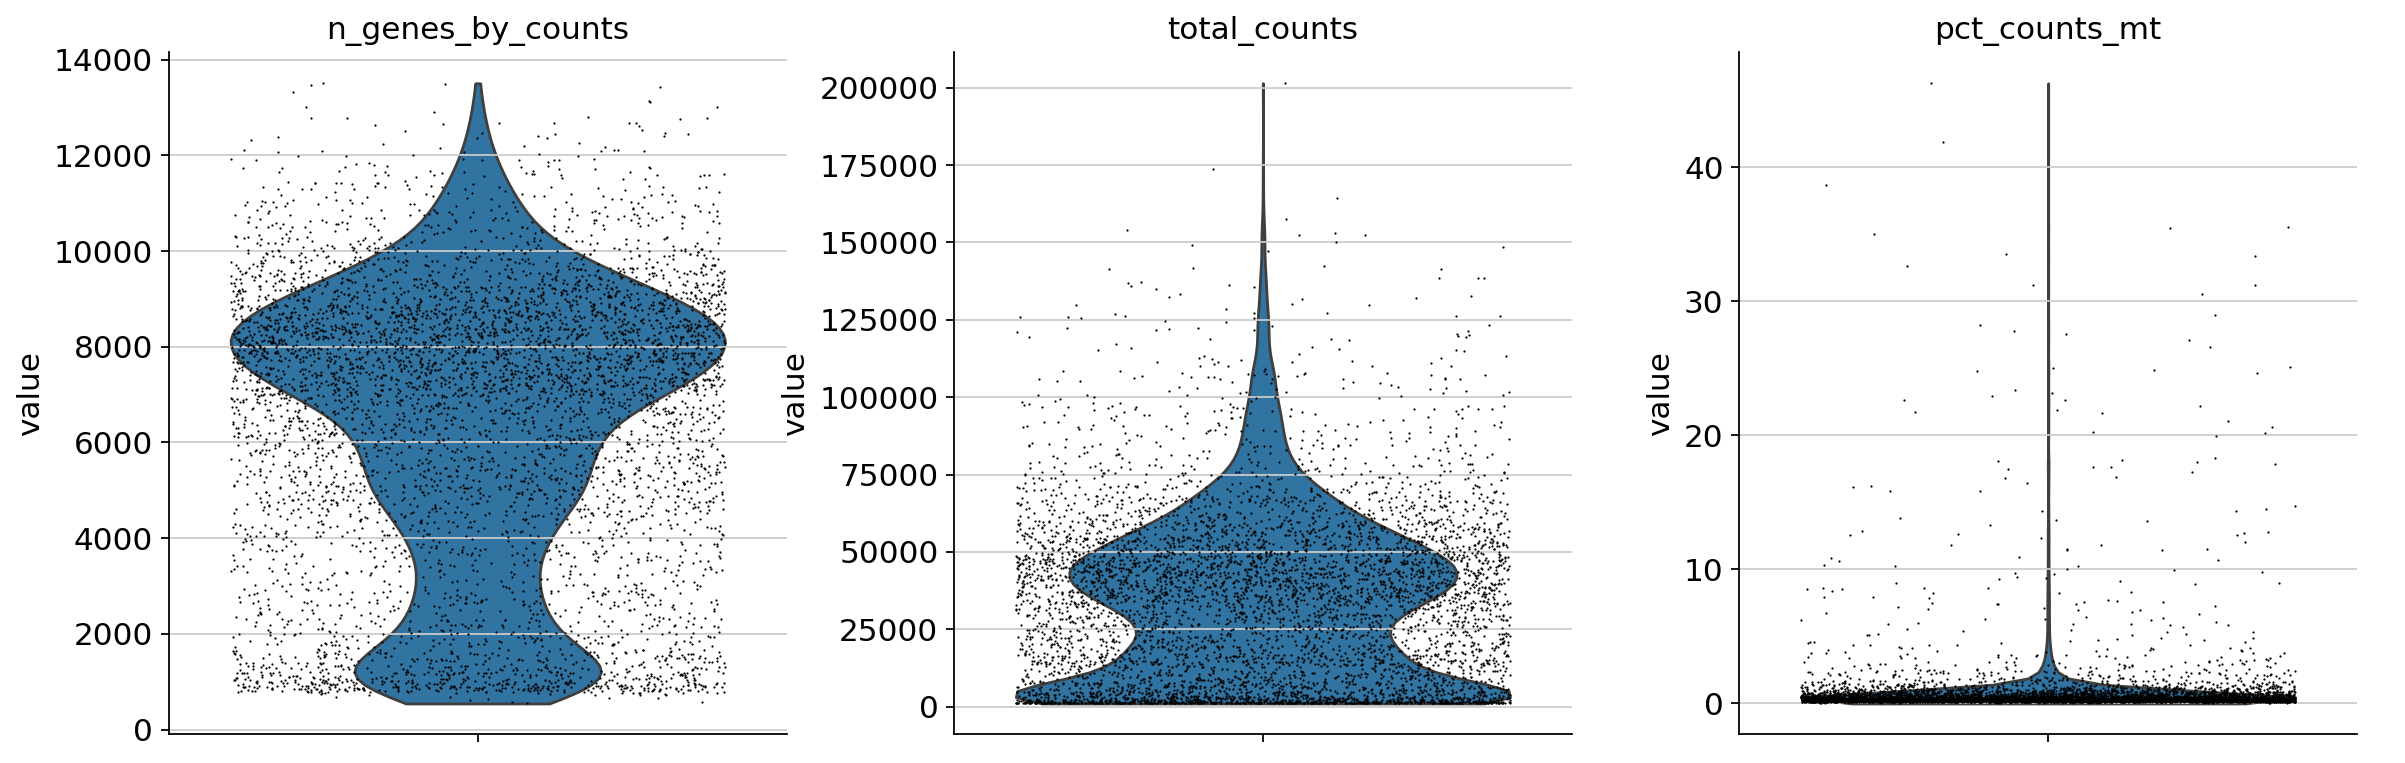

In [14]:
sample = 'd1'

sc.pl.violin(adatas[sample],
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,)

In [15]:
# Filter cells and genes
sc.pp.filter_cells(adatas[sample], min_genes=100)
sc.pp.filter_genes(adatas[sample], min_cells=3)

# Define filters
cell_filter = (adatas[sample].obs.n_genes_by_counts < 12000) & \
              (adatas[sample].obs.total_counts < 175000) & \
              (adatas[sample].obs.pct_counts_mt < 5)

# Apply filters
adatas[sample] = adatas[sample][cell_filter, :].copy()

adatas[sample]

filtered out 2758 genes that are detected in less than 3 cells


AnnData object with n_obs × n_vars = 5711 × 30729
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'gene_symbols', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'

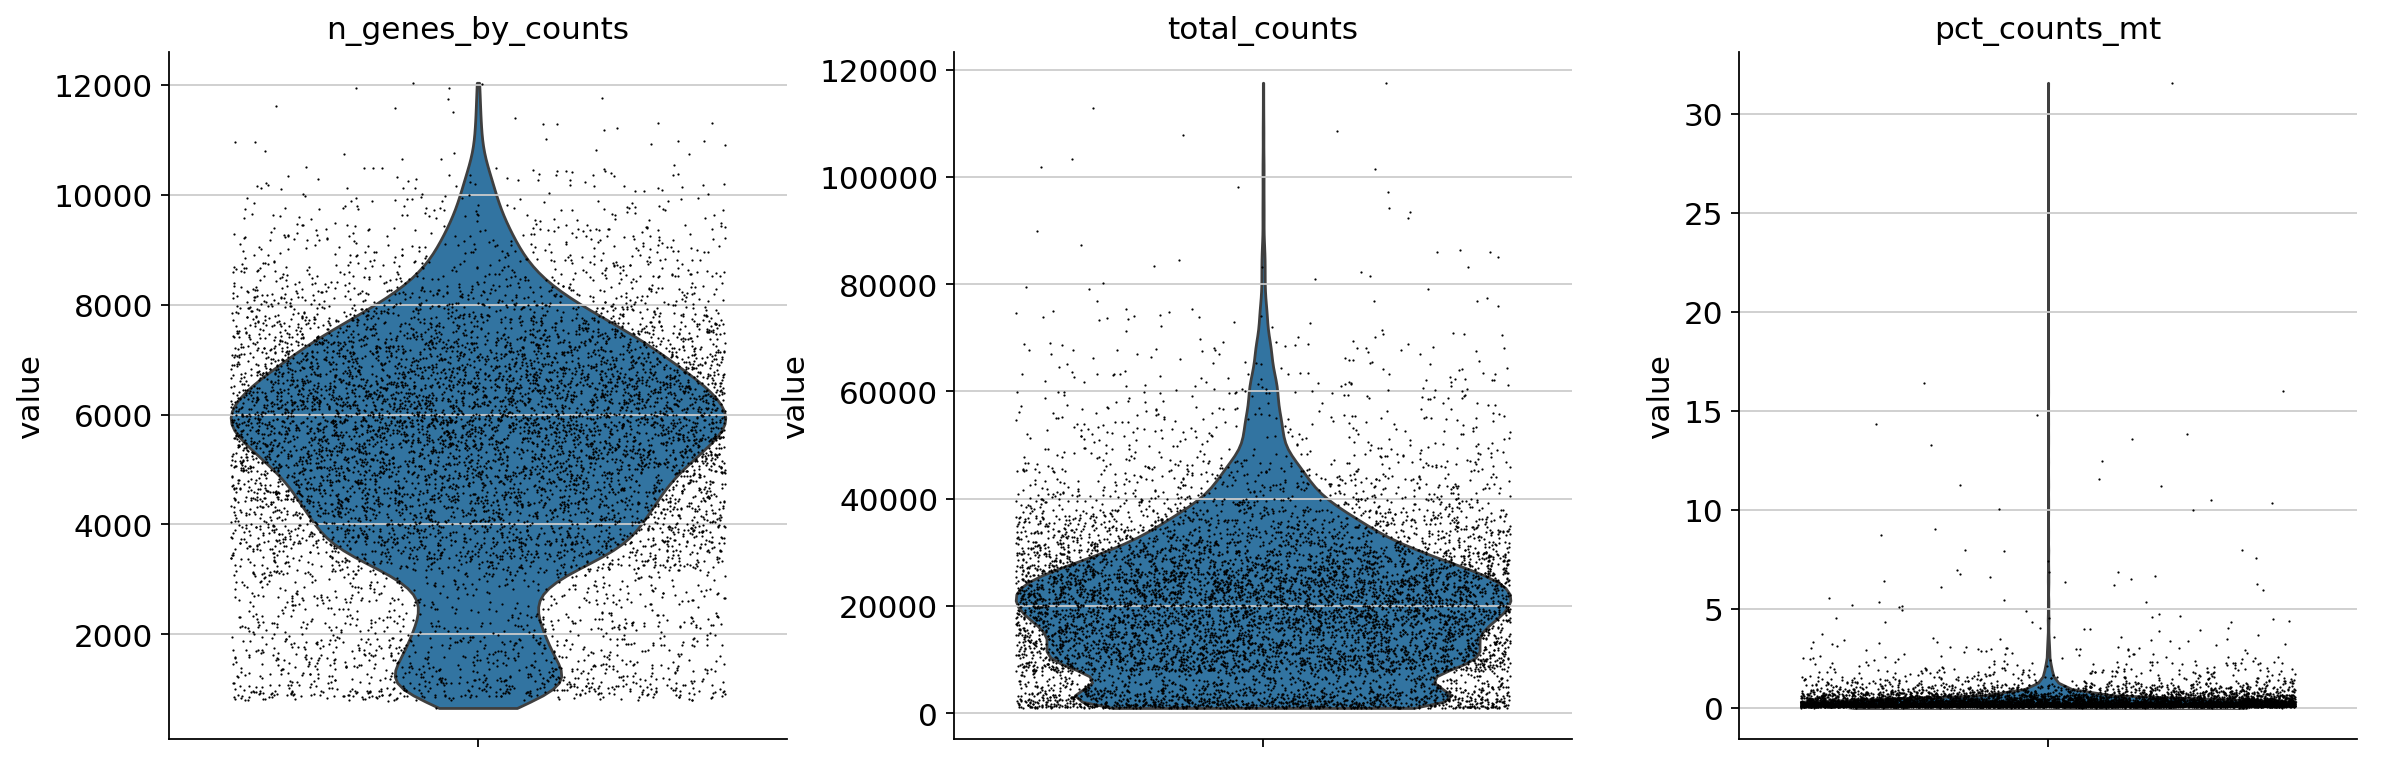

In [16]:
sample = 'd2'

sc.pl.violin(adatas[sample],
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,)

In [17]:
# Filter cells and genes
sc.pp.filter_cells(adatas[sample], min_genes=100)
sc.pp.filter_genes(adatas[sample], min_cells=3)

# Define filters
cell_filter = (adatas[sample].obs.n_genes_by_counts < 11000) & \
              (adatas[sample].obs.total_counts < 100000) & \
              (adatas[sample].obs.pct_counts_mt < 5)

# Apply filters
adatas[sample] = adatas[sample][cell_filter, :].copy()

adatas[sample]

filtered out 2810 genes that are detected in less than 3 cells


AnnData object with n_obs × n_vars = 8374 × 30526
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'gene_symbols', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'

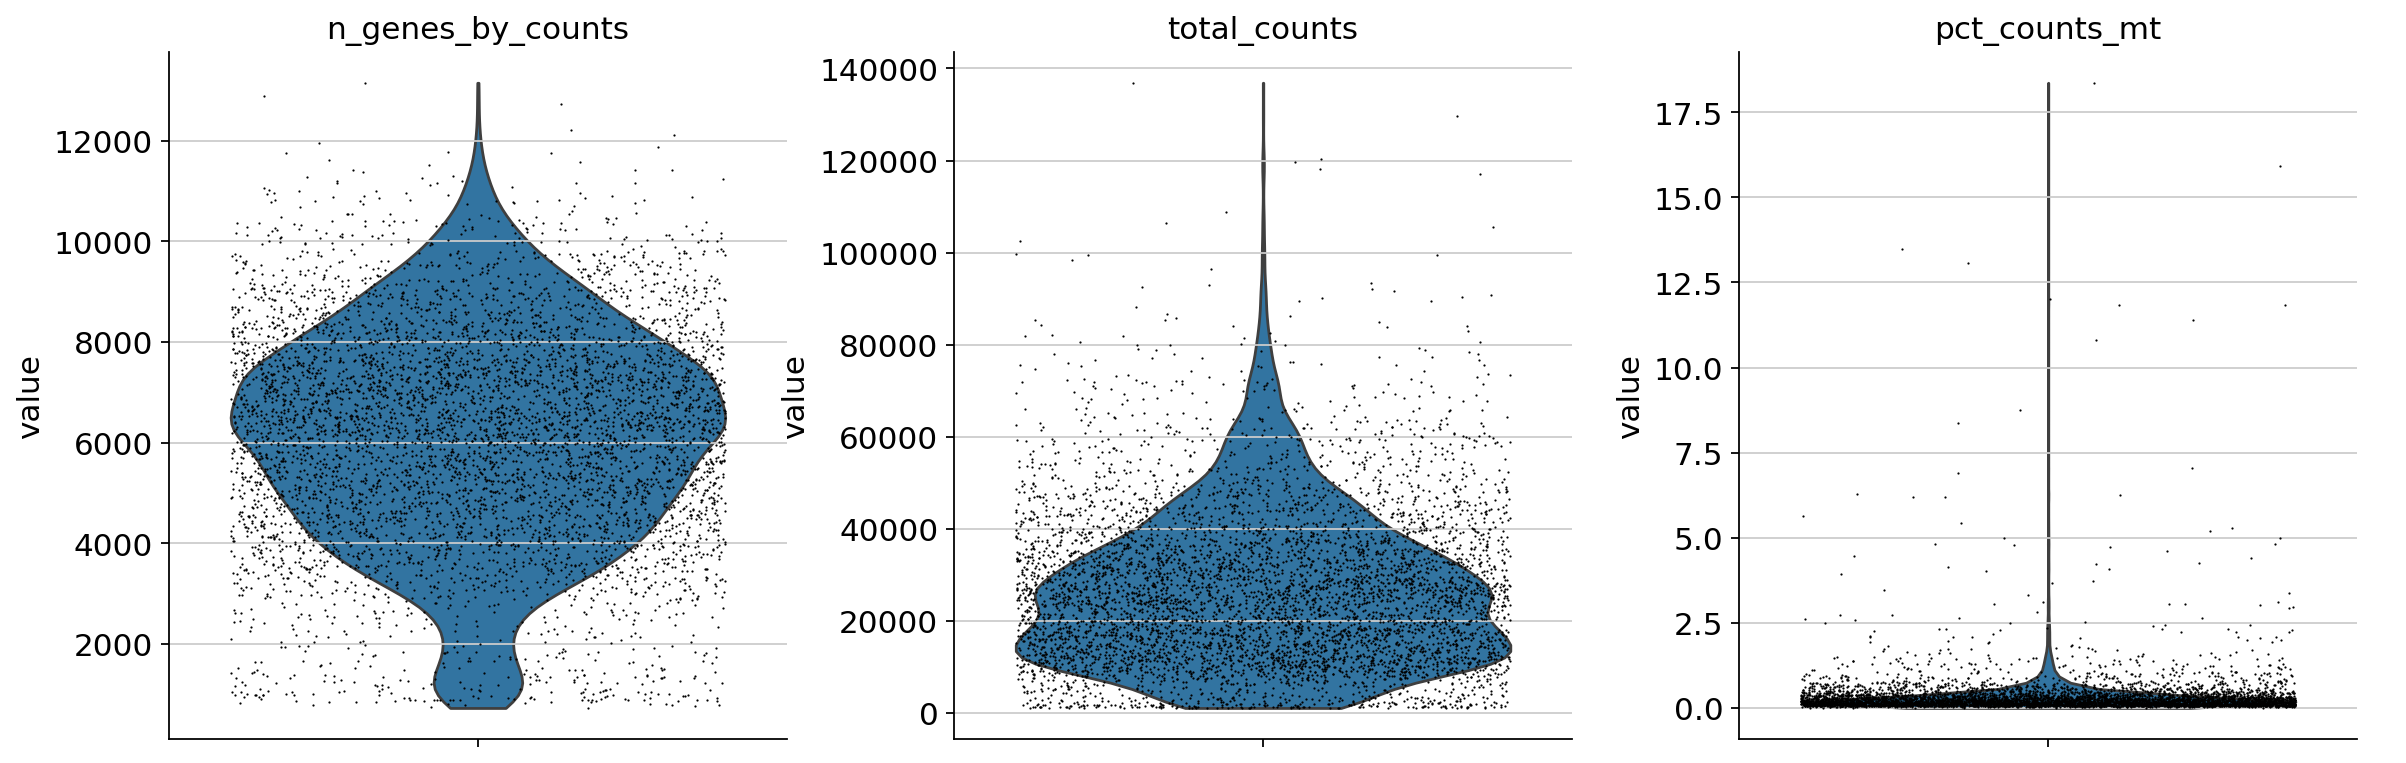

In [18]:
sample = 'd3'

sc.pl.violin(adatas[sample],
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,)

In [19]:
# Filter cells and genes
sc.pp.filter_cells(adatas[sample], min_genes=100)
sc.pp.filter_genes(adatas[sample], min_cells=3)

# Define filters
cell_filter = (adatas[sample].obs.n_genes_by_counts < 12000) & \
              (adatas[sample].obs.total_counts < 100000) & \
              (adatas[sample].obs.pct_counts_mt < 5)

# Apply filters
adatas[sample] = adatas[sample][cell_filter, :].copy()

adatas[sample]

filtered out 2835 genes that are detected in less than 3 cells


AnnData object with n_obs × n_vars = 5695 × 30164
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'gene_symbols', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'

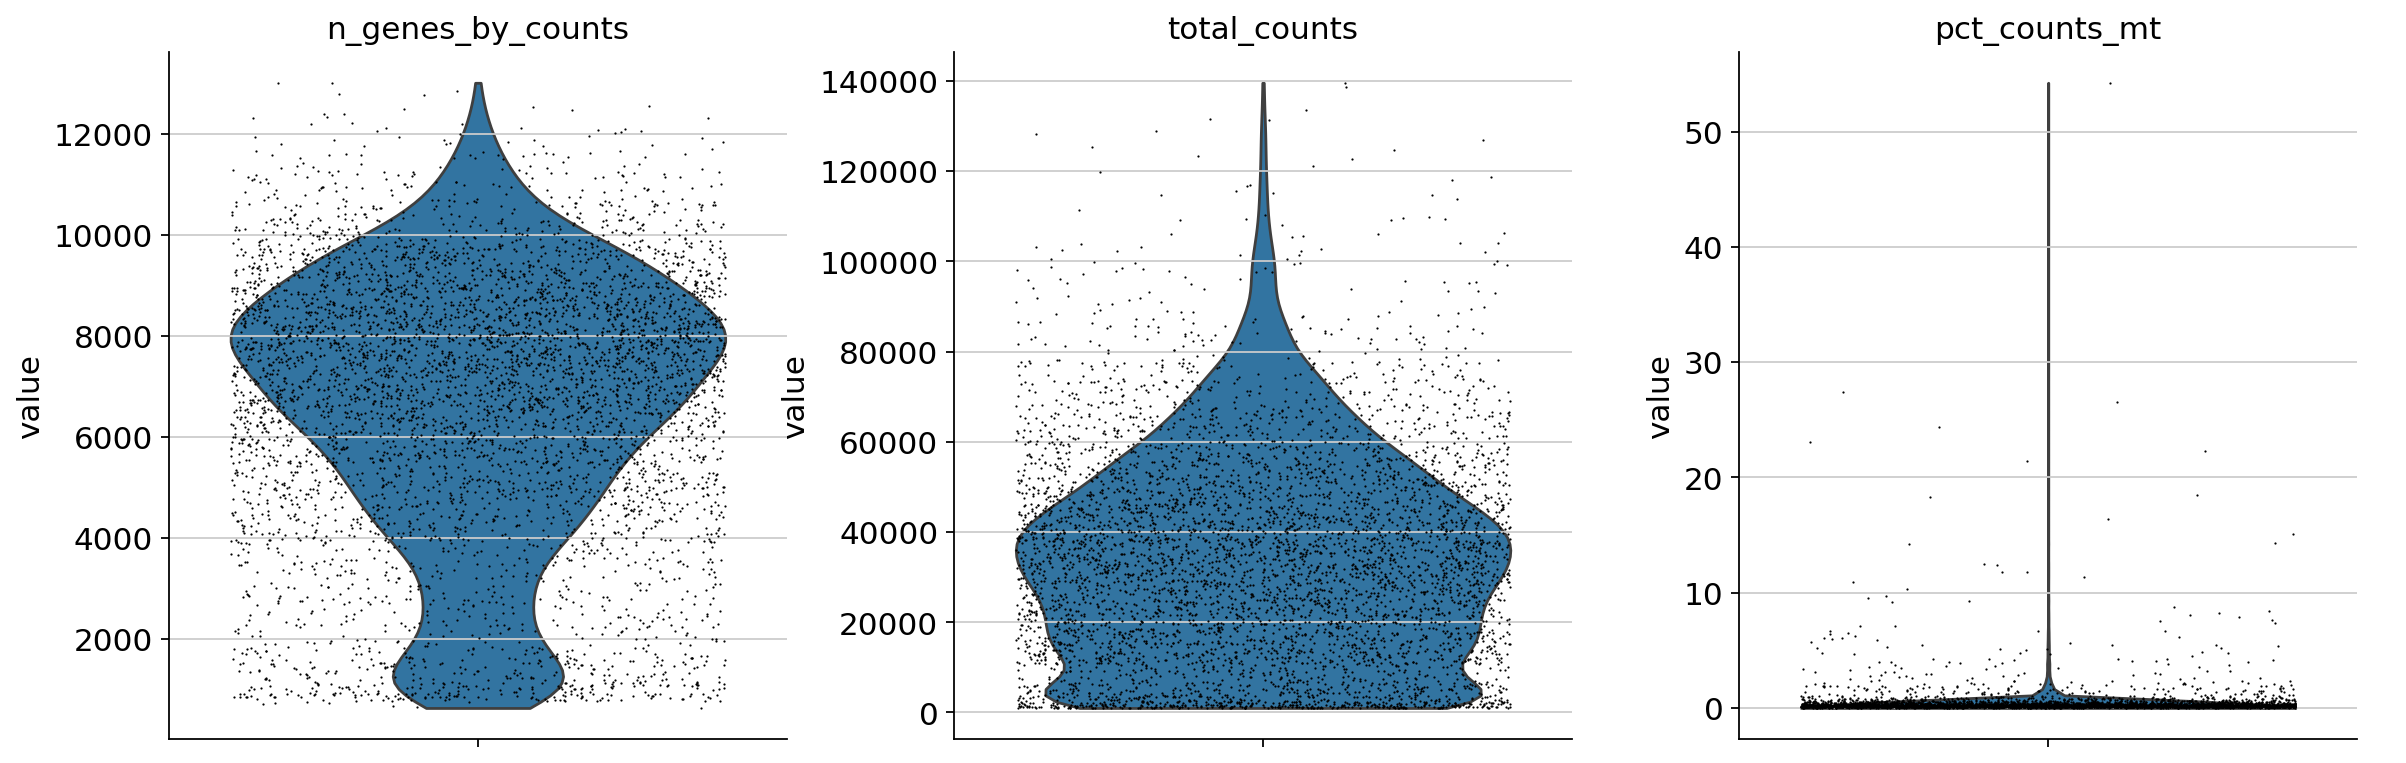

In [20]:
sample = 'd4'

sc.pl.violin(adatas[sample],
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,)

In [21]:
# Filter cells and genes
sc.pp.filter_cells(adatas[sample], min_genes=100)
sc.pp.filter_genes(adatas[sample], min_cells=3)

# Define filters
cell_filter = (adatas[sample].obs.n_genes_by_counts < 12000) & \
              (adatas[sample].obs.total_counts < 120000) & \
              (adatas[sample].obs.pct_counts_mt < 5)

# Apply filters
adatas[sample] = adatas[sample][cell_filter, :].copy()

adatas[sample]

filtered out 2641 genes that are detected in less than 3 cells


AnnData object with n_obs × n_vars = 5160 × 30594
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'gene_symbols', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'

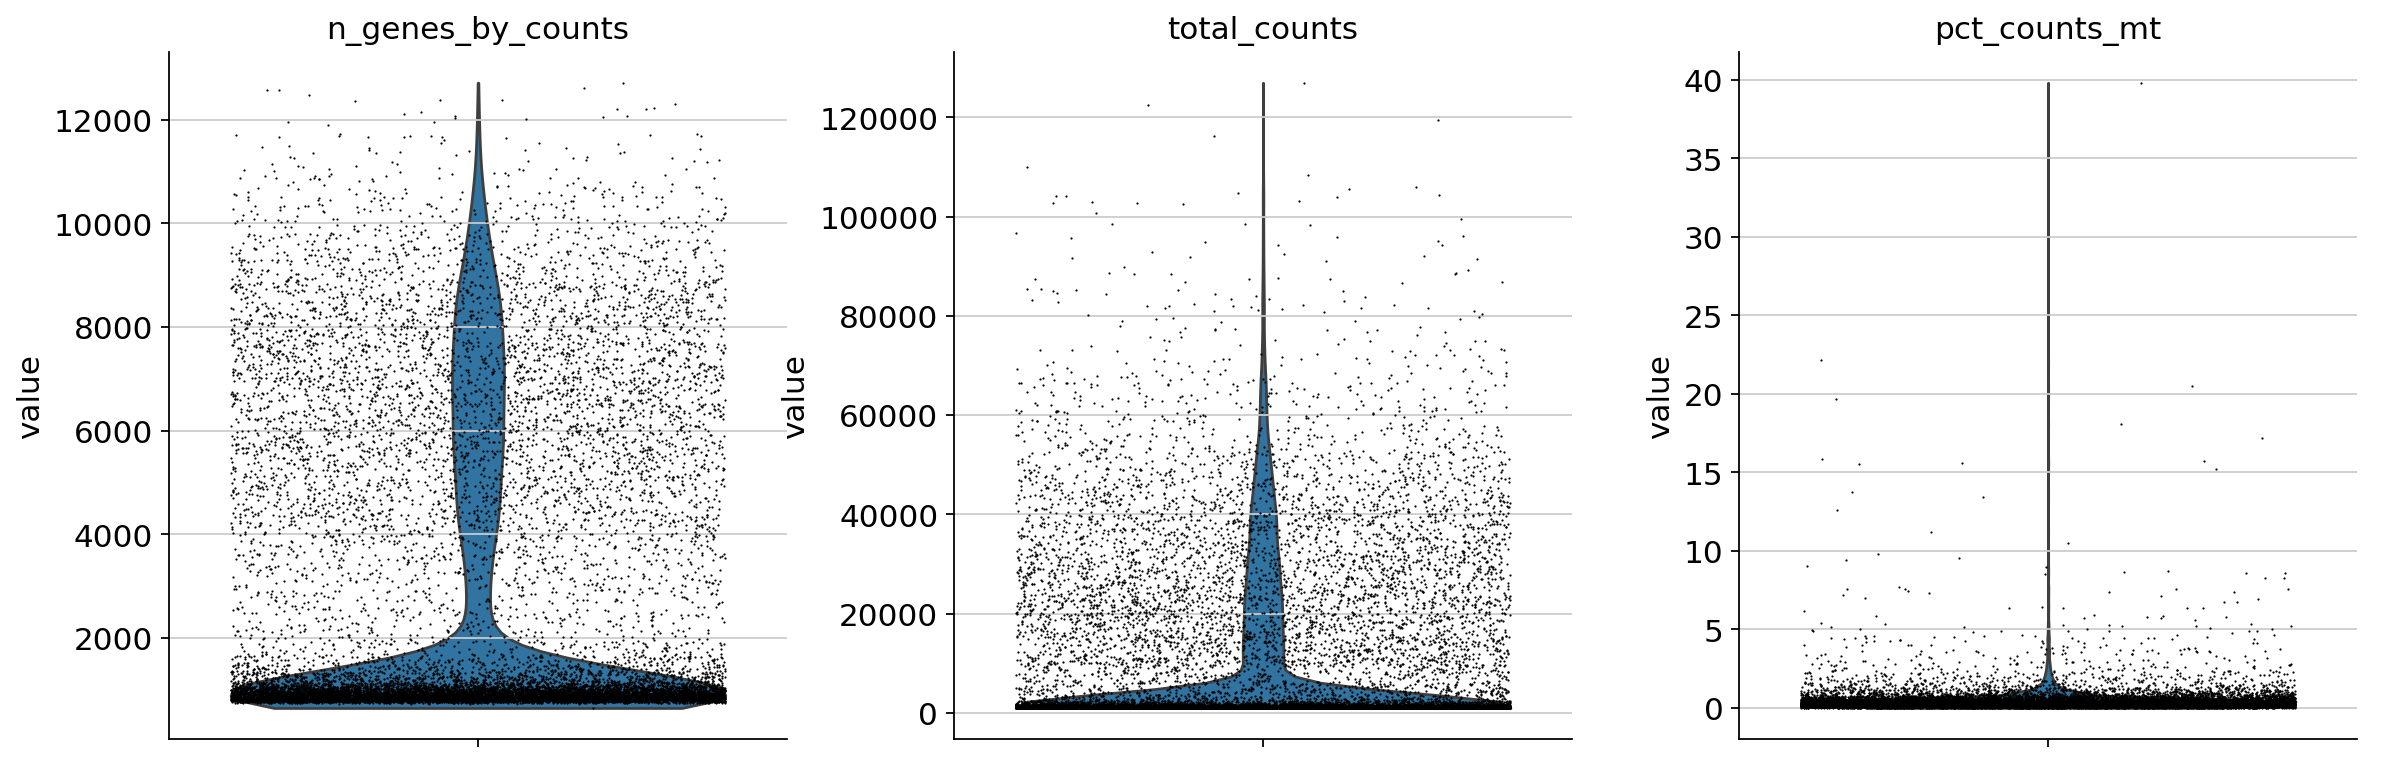

In [22]:
sample = 'd5'

sc.pl.violin(adatas[sample],
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,)

In [23]:
# Filter cells and genes
sc.pp.filter_cells(adatas[sample], min_genes=100)
sc.pp.filter_genes(adatas[sample], min_cells=3)

# Define filters
cell_filter = (adatas[sample].obs.n_genes_by_counts < 11000) & \
              (adatas[sample].obs.total_counts < 100000) & \
              (adatas[sample].obs.pct_counts_mt < 5)

# Apply filters
adatas[sample] = adatas[sample][cell_filter, :].copy()

adatas[sample]

filtered out 2354 genes that are detected in less than 3 cells


AnnData object with n_obs × n_vars = 15435 × 31498
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'gene_symbols', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'

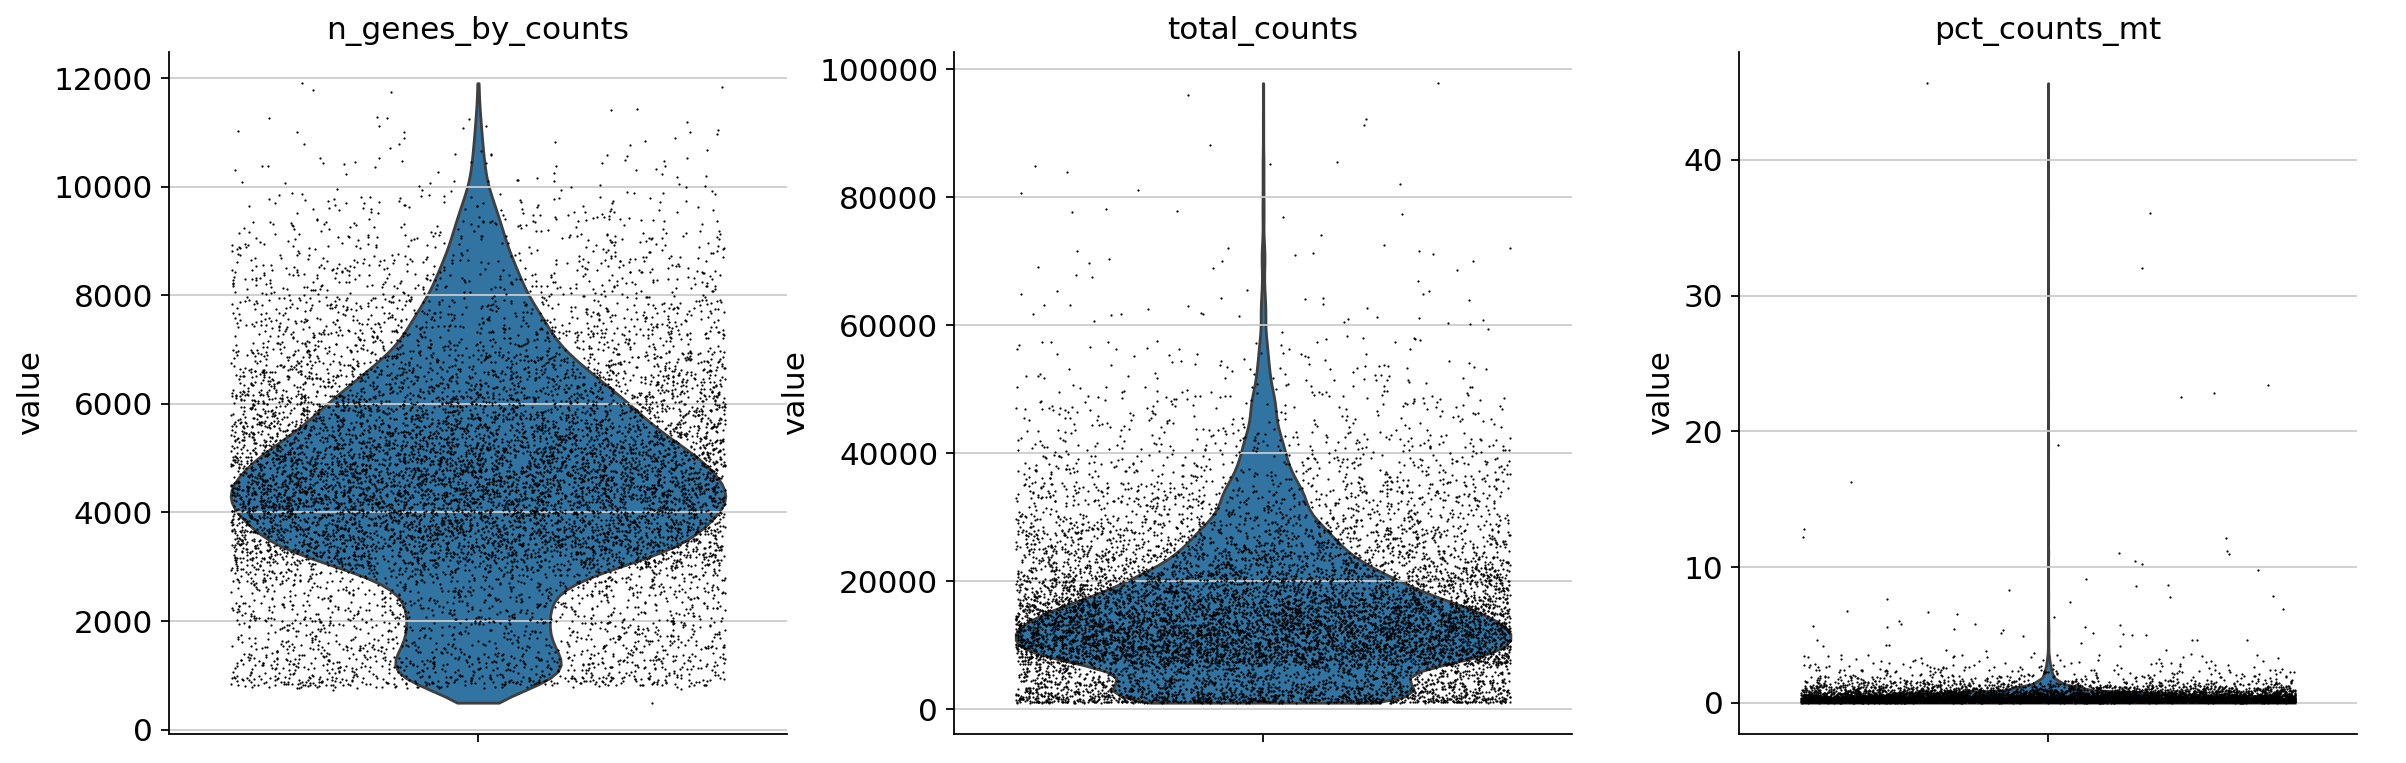

In [24]:
sample = 'd6'

sc.pl.violin(adatas[sample],
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,)

In [25]:
# Filter cells and genes
sc.pp.filter_cells(adatas[sample], min_genes=100)
sc.pp.filter_genes(adatas[sample], min_cells=3)

# Define filters
cell_filter = (adatas[sample].obs.n_genes_by_counts < 10000) & \
              (adatas[sample].obs.total_counts < 80000) & \
              (adatas[sample].obs.pct_counts_mt < 5)

# Apply filters
adatas[sample] = adatas[sample][cell_filter, :].copy()

adatas[sample]

filtered out 2530 genes that are detected in less than 3 cells


AnnData object with n_obs × n_vars = 10526 × 31204
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'gene_symbols', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'

In [26]:
adatas

{'d1': AnnData object with n_obs × n_vars = 5711 × 30729
     obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes'
     var: 'gene_symbols', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells',
 'd2': AnnData object with n_obs × n_vars = 8374 × 30526
     obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes'
     var: 'gene_symbols', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_co

In [27]:
adata = ad.concat(adatas, label="sample")

/mnt/yiming/nfs_share/anaconda3/envs/scanpy/lib/python3.11/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [28]:
adata.obs_names_make_unique()

In [29]:
sc.pp.scrublet(adata, batch_key="sample")

Running Scrublet
filtered out 20 genes that are detected in less than 3 cells
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
Embedding transcriptomes using PCA...
    using data matrix X directly
Automatically set threshold at doublet score = 0.56
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 0.2%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 0.0%
filtered out 9 genes that are detected in less than 3 cells
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)


In [30]:
adata

AnnData object with n_obs × n_vars = 50901 × 28308
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet'
    uns: 'scrublet'

In [31]:
adata = adata[adata.obs['predicted_doublet'] == False]

In [33]:
adata.write_h5ad('/mnt/yiming/nfs_share/hema_wave/hemo-bgi-d1-6-rna.h5ad')

/mnt/yiming/nfs_share/anaconda3/envs/scanpy/lib/python3.11/site-packages/anndata/_core/anndata.py:1230: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


### day 7-10

In [5]:
samples = {'day7': '/mnt/yunzhiyang/nfs_share2/05.scRNA_dnbc4tools/05.scRNA_dnbc4tools_1210_T7/01.result/Yiming_day7/output/filter_feature.h5ad',
 'day9': '/mnt/yunzhiyang/nfs_share2/05.scRNA_dnbc4tools/05.scRNA_dnbc4tools_1210_T7/01.result/Yiming_day9/output/filter_feature.h5ad',
 'day10': '/mnt/yunzhiyang/nfs_share2/05.scRNA_dnbc4tools/05.scRNA_dnbc4tools_1210_T7/01.result/Yiming_day10/output/filter_feature.h5ad',
 'day8': '/mnt/yunzhiyang/nfs_share2/05.scRNA_dnbc4tools/05.scRNA_dnbc4tools_20250124/02.result/yiming_day8/output/filter_feature.h5ad'}

In [6]:
for sample_name, sample_path in samples.items():
    adatas[sample_name].var["mt"] = adatas[sample_name].var_names.str.startswith("MT-") 
    sc.pp.calculate_qc_metrics(adatas[sample_name], qc_vars=["mt"], inplace=True, log1p=True)

In [7]:
adatas

{'day7': AnnData object with n_obs × n_vars = 6320 × 35002
     obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
     var: 'gene_symbols', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts',
 'day9': AnnData object with n_obs × n_vars = 4678 × 34473
     obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
     var: 'gene_symbols', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts',


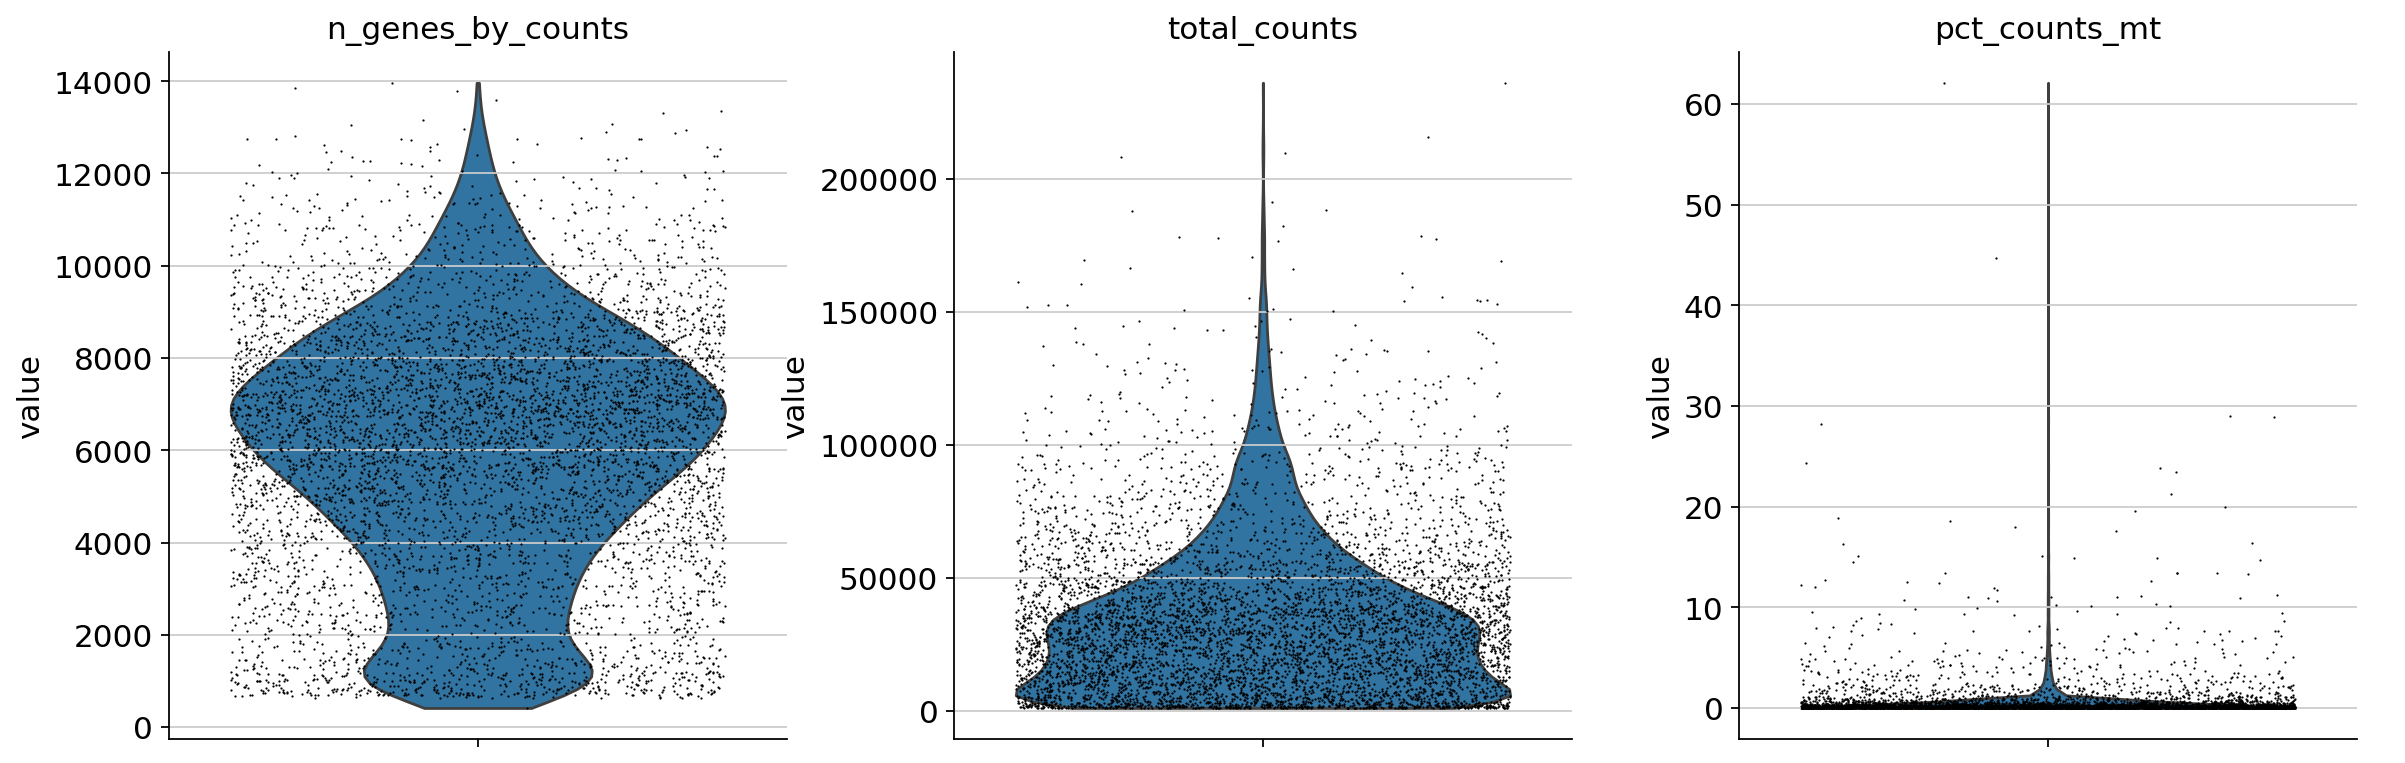

In [8]:
sample = 'day7'

sc.pl.violin(adatas[sample],
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,)

In [9]:
# Filter cells and genes
sc.pp.filter_cells(adatas[sample], min_genes=100)
sc.pp.filter_genes(adatas[sample], min_cells=3)

# Define filters
cell_filter = (adatas[sample].obs.n_genes_by_counts < 12000) & \
              (adatas[sample].obs.total_counts < 150000) & \
              (adatas[sample].obs.pct_counts_mt < 5)

# Apply filters
adatas[sample] = adatas[sample][cell_filter, :].copy()

adatas[sample]

filtered out 2698 genes that are detected in less than 3 cells


AnnData object with n_obs × n_vars = 6120 × 32304
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'gene_symbols', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'

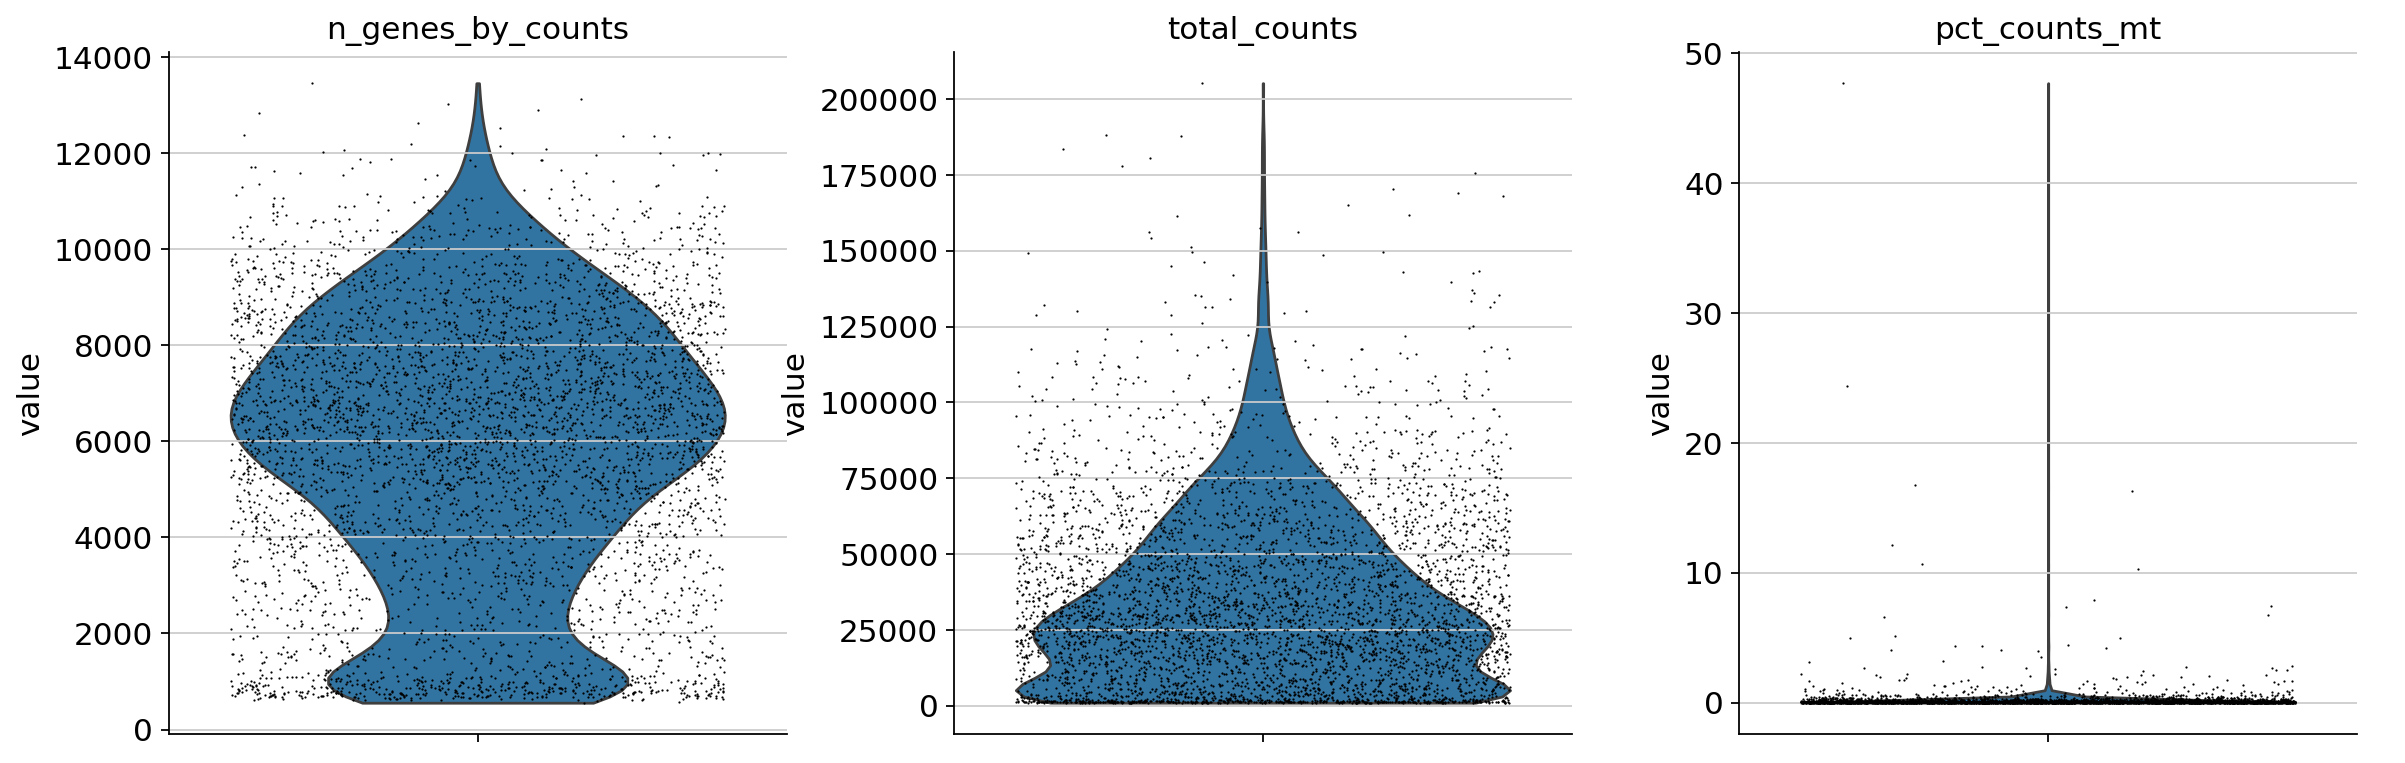

In [10]:
sample = 'day9'

sc.pl.violin(adatas[sample],
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,)

In [11]:
# Filter cells and genes
sc.pp.filter_cells(adatas[sample], min_genes=100)
sc.pp.filter_genes(adatas[sample], min_cells=3)

# Define filters
cell_filter = (adatas[sample].obs.n_genes_by_counts < 12000) & \
              (adatas[sample].obs.total_counts < 125000) & \
              (adatas[sample].obs.pct_counts_mt < 5)

# Apply filters
adatas[sample] = adatas[sample][cell_filter, :].copy()

adatas[sample]

filtered out 2946 genes that are detected in less than 3 cells


AnnData object with n_obs × n_vars = 4613 × 31527
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'gene_symbols', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'

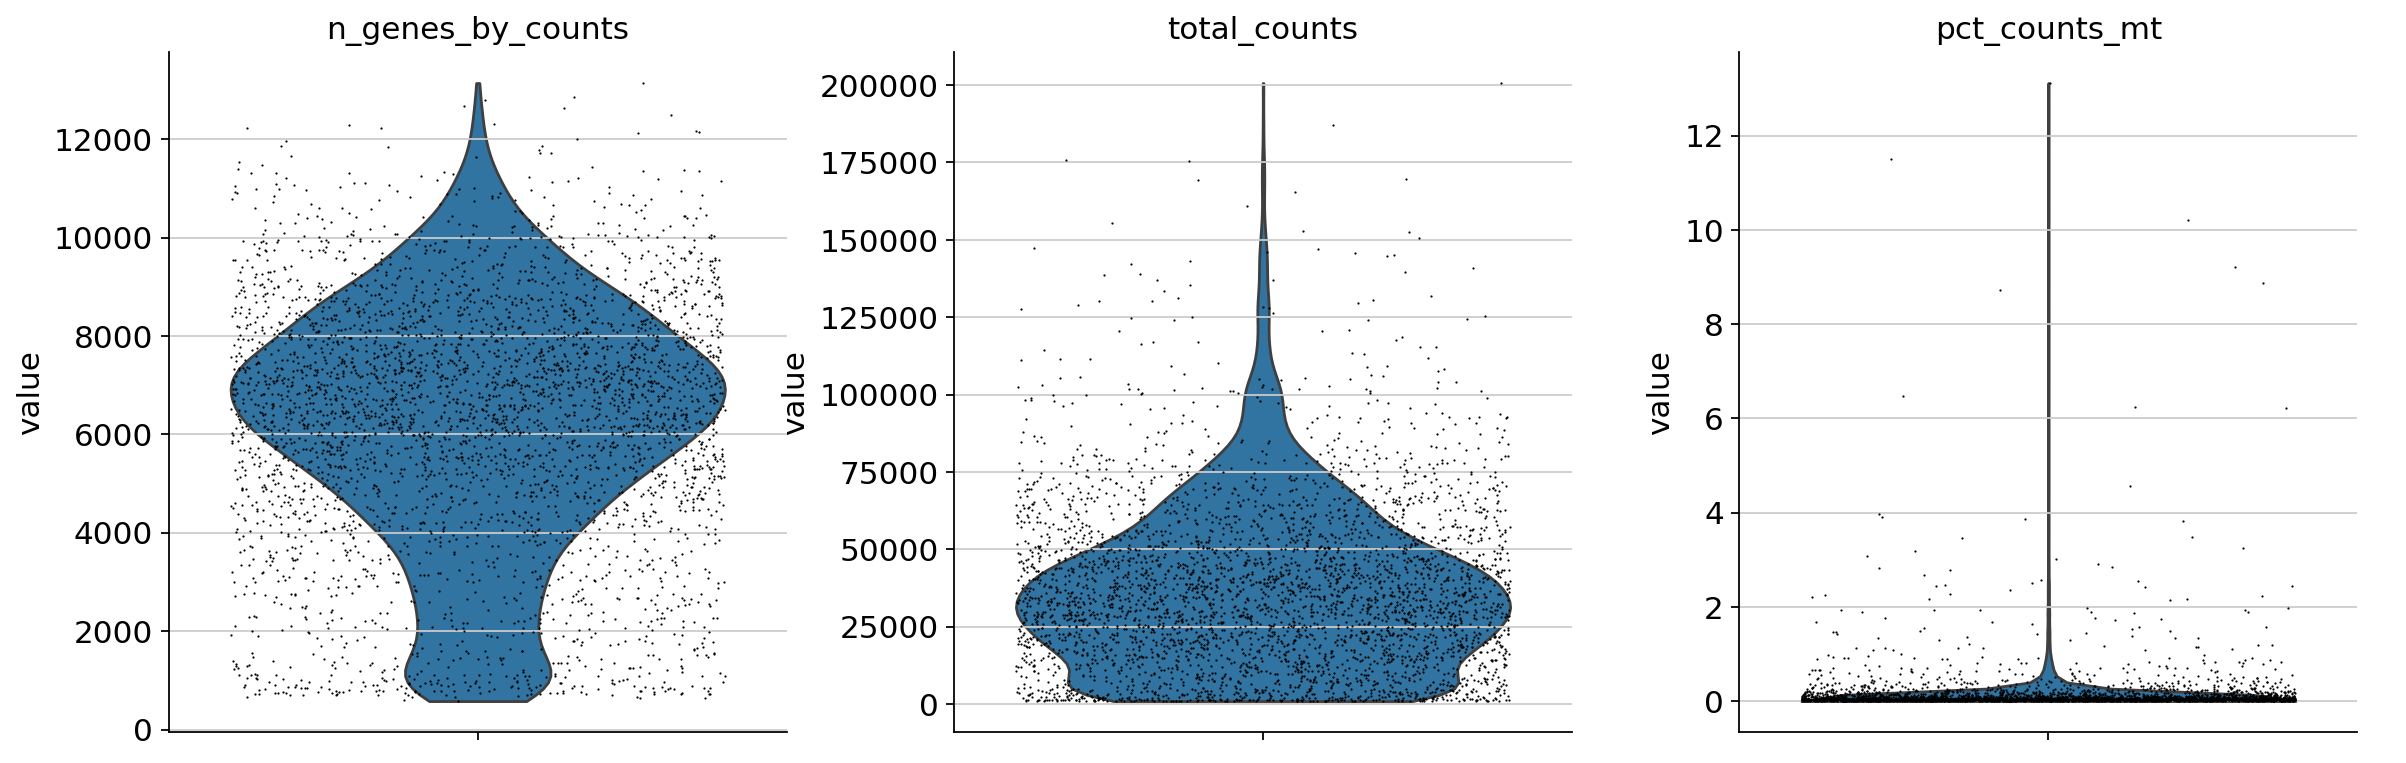

In [12]:
sample = 'day10'

sc.pl.violin(adatas[sample],
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,)

In [13]:
# Filter cells and genes
sc.pp.filter_cells(adatas[sample], min_genes=100)
sc.pp.filter_genes(adatas[sample], min_cells=3)

# Define filters
cell_filter = (adatas[sample].obs.n_genes_by_counts < 12000) & \
              (adatas[sample].obs.total_counts < 125000) & \
              (adatas[sample].obs.pct_counts_mt < 5)

# Apply filters
adatas[sample] = adatas[sample][cell_filter, :].copy()

adatas[sample]

filtered out 3051 genes that are detected in less than 3 cells


AnnData object with n_obs × n_vars = 3837 × 30958
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'gene_symbols', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'

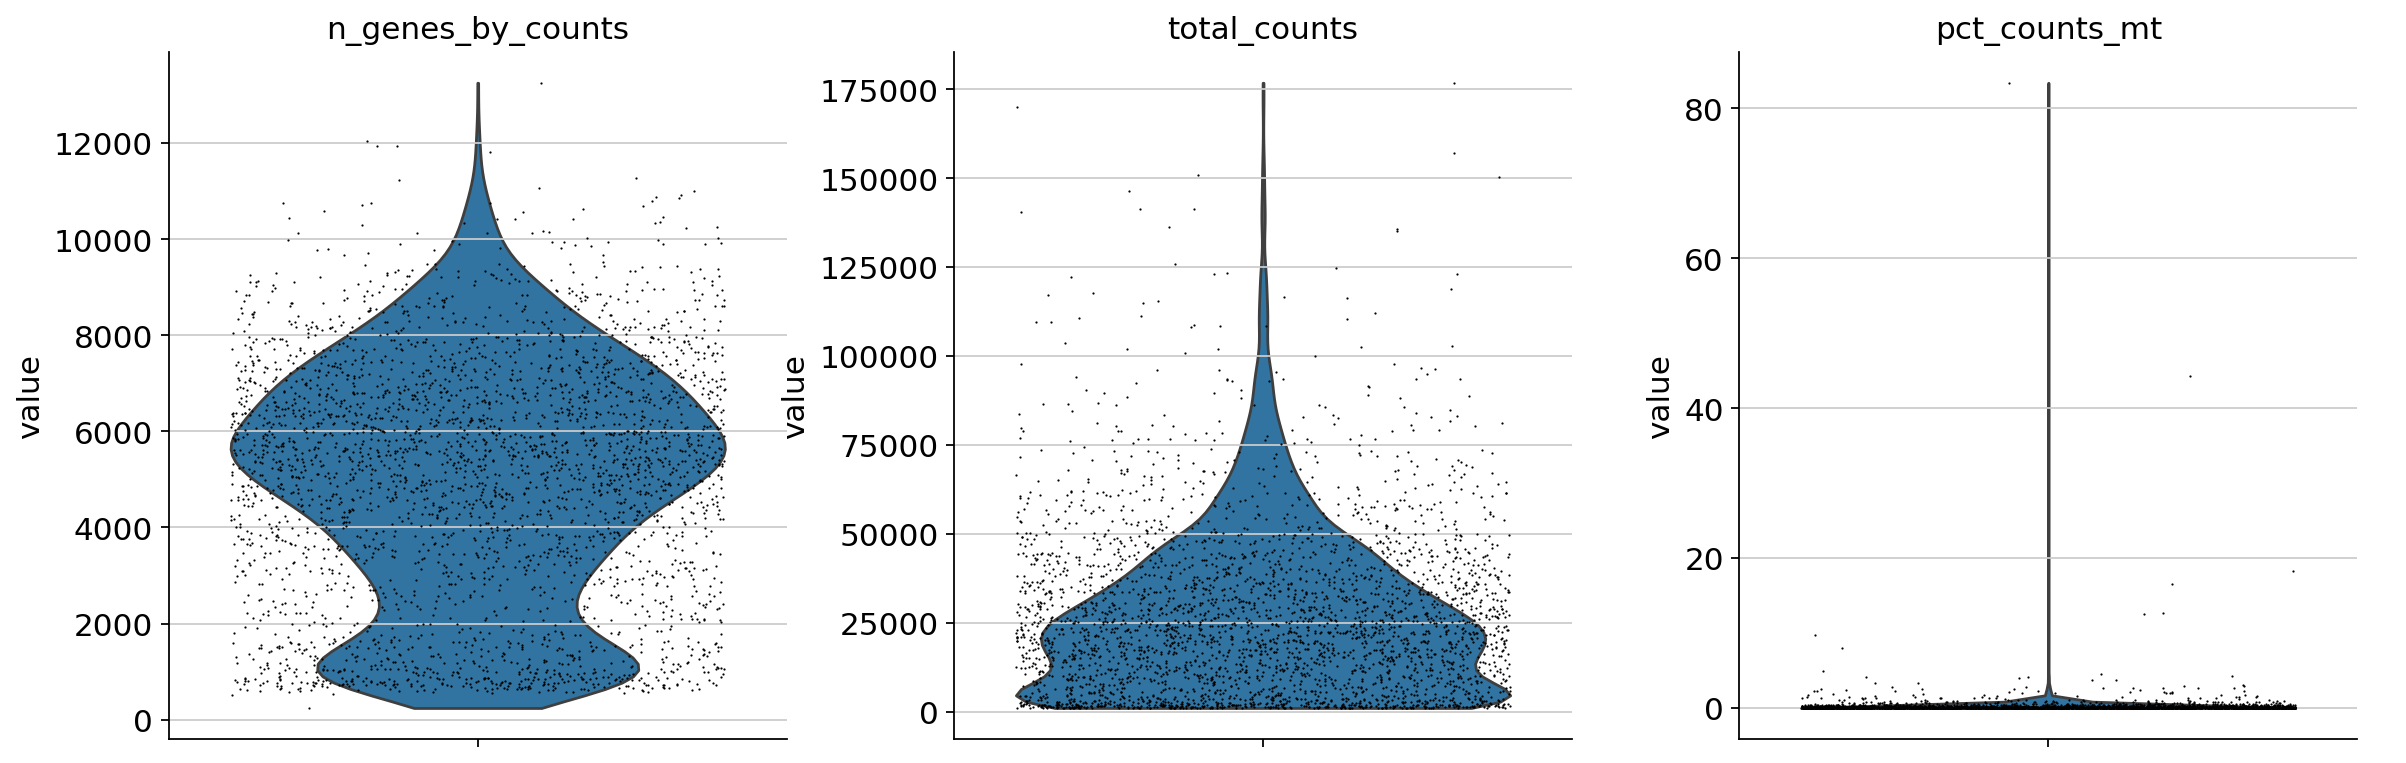

In [14]:
sample = 'day8'

sc.pl.violin(adatas[sample],
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,)

In [15]:
# Filter cells and genes
sc.pp.filter_cells(adatas[sample], min_genes=100)
sc.pp.filter_genes(adatas[sample], min_cells=3)

# Define filters
cell_filter = (adatas[sample].obs.n_genes_by_counts < 12000) & \
              (adatas[sample].obs.total_counts < 125000) & \
              (adatas[sample].obs.pct_counts_mt < 5)

# Apply filters
adatas[sample] = adatas[sample][cell_filter, :].copy()

adatas[sample]

filtered out 3608 genes that are detected in less than 3 cells


AnnData object with n_obs × n_vars = 3223 × 29360
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'gene_symbols', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'

In [16]:
adata = ad.concat(adatas, label="sample")

/mnt/yiming/nfs_share/anaconda3/envs/scanpy/lib/python3.11/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [17]:
adata.obs_names_make_unique()

In [18]:
adata.obs['sample'] = adata.obs['sample'].replace({'day7': 'd7', 'day8': 'd8', 'day9': 'd9', 'day10': 'd10'})

In [19]:
adata.obs

,sample,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,n_genes
CELL3_N2,d7,7906,8.975504,56895.0,10.948980,20.430618,31.526496,42.606556,56.340627,79.0,4.382027,0.138852,7906
CELL8_N2,d7,6038,8.705994,30861.0,10.337281,23.644730,35.928842,47.318622,60.279965,25.0,3.258096,0.081008,6038
CELL12_N2,d7,8945,9.098962,69193.0,11.144670,18.357348,29.104100,39.674534,53.378232,137.0,4.927254,0.197997,8945
CELL15_N2,d7,5936,8.688959,24564.0,10.109077,23.803127,34.574988,44.145905,56.216414,16.0,2.833213,0.065136,5936
CELL19_N2,d7,7243,8.887929,40284.0,10.603734,23.907755,35.358951,45.678185,58.045378,25.0,3.258096,0.062059,7243
...,...,...,...,...,...,...,...,...,...,...,...,...,...
CELL57847_N1,d8,4490,8.409831,15603.0,9.655283,24.065885,35.467538,44.984939,57.726078,5.0,1.791759,0.032045,4490
CELL57856_N1,d8,7757,8.956480,55023.0,10.915524,21.016666,32.313760,43.105610,56.879850,7.0,2.079442,0.012722,7757
CELL57867_N1,d8,1635,7.400010,3765.0,8.233768,24.913679,36.626826,48.605578,67.490040,1.0,0.693147,0.026560,1635
CELL57917_N1,d8,6616,8.797397,22916.0,10.039635,12.467272,17.668878,25.056729,38.898586,226.0,5.424950,0.986211,6616


In [20]:
sc.pp.scrublet(adata, batch_key="sample")

Running Scrublet
filtered out 43 genes that are detected in less than 3 cells
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
Embedding transcriptomes using PCA...
    using data matrix X directly
Automatically set threshold at doublet score = 0.23
Detected doublet rate = 1.9%
Estimated detectable doublet fraction = 40.5%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 4.8%
filtered out 28 genes that are detected in less than 3 cells
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var

In [21]:
adata

AnnData object with n_obs × n_vars = 17793 × 28240
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet'
    uns: 'scrublet'

In [22]:
adata = adata[adata.obs['predicted_doublet'] == False]

In [26]:
adata.write_h5ad('/mnt/yiming/nfs_share/hema_wave/hemo-bgi-d7-10-rna.h5ad')